In [1]:
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F

# Scaled Dot-Product Attention Operator

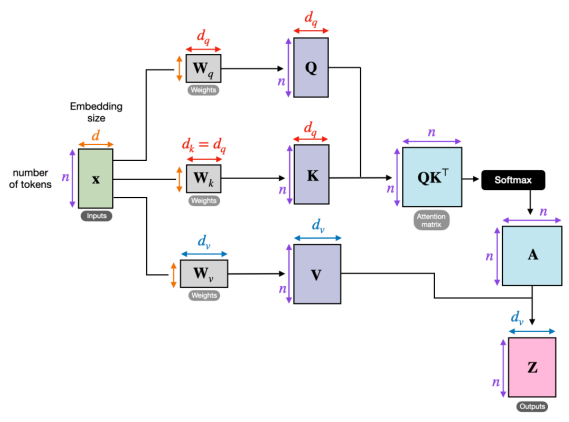

In [ ]:
# Define a function 'scaled_dot_product_attention' which computes the attention weights
# and the aggregated values

# Arguments with length T:
# 1) "q": query tensor (b, T, dk)
# 2) "k": key tensor (b, T, dk)
# 3) "v": value tensor (b, T, dv)

# Attention(Q, K, V) = softmax[(QK.T) / sqrt(dk)]*V

# Output: resulting output tensor

#   "b" (numero di canali o 'batch size'): dimensione del batch --> PROFONDITà
#   cioè quante sequenze vengono elaborate in parallelo in quel preciso istante 
#   "T" è la lunghezza della sequenza, cioè quanti 'token' --> RIGHE
#   "dk" lunghezza del vettore --> COLONNE

# LE DIMENSIONI SONO NELL'IMMAGINE SOPRA (n = T)

In [17]:
def scaled_dot_product_attention(q, k, v):
    k_T = k.transpose(1, 2)
    dot_product = torch.bmm(q, k_T) / np.sqrt(k.shape[-1])
    
    # debug
    print("dot_product shape:", dot_product.shape)
    
    sm = F.softmax(dot_product, dim=-1)
    return torch.bmm(sm, v)
    

In [ ]:
# shape: b, T, dk (cioè: profondità, righe, colonne)
q = torch.arange(3*4*2).reshape((3, 4, 2)).float()
k = torch.arange(3*4*2).reshape((3, 4, 2)).float()

v = torch.arange(3*4*5).reshape((3, 4, 5)).float()

In [ ]:
weigths = scaled_dot_product_attention(q, k, v)

# dot_product matrix = q * k_T = (4, 2) x (2, 4) = (4, 4)
# weigths matrix = dot_product * V = (4, 4) x (4, 5) = (4, 5)

dot_product shape: torch.Size([3, 4, 4])


In [21]:
# output
print("weigths shape:", weigths.shape, '\n')
weigths

weigths shape: torch.Size([3, 4, 5]) 



tensor([[[13.4641, 14.4641, 15.4641, 16.4641, 17.4641],
         [14.9957, 15.9957, 16.9958, 17.9957, 18.9957],
         [15.0000, 16.0000, 17.0000, 18.0000, 19.0000],
         [15.0000, 16.0000, 17.0000, 18.0000, 19.0000]],

        [[35.0000, 36.0000, 37.0000, 38.0000, 39.0000],
         [35.0000, 36.0000, 37.0000, 38.0000, 39.0000],
         [35.0000, 36.0000, 37.0000, 38.0000, 39.0000],
         [35.0000, 36.0000, 37.0000, 38.0000, 39.0000]],

        [[55.0000, 56.0000, 57.0000, 58.0000, 59.0000],
         [55.0000, 56.0000, 57.0000, 58.0000, 59.0000],
         [55.0000, 56.0000, 57.0000, 58.0000, 59.0000],
         [55.0000, 56.0000, 57.0000, 58.0000, 59.0000]]])

# Vision Transformer (ViT)

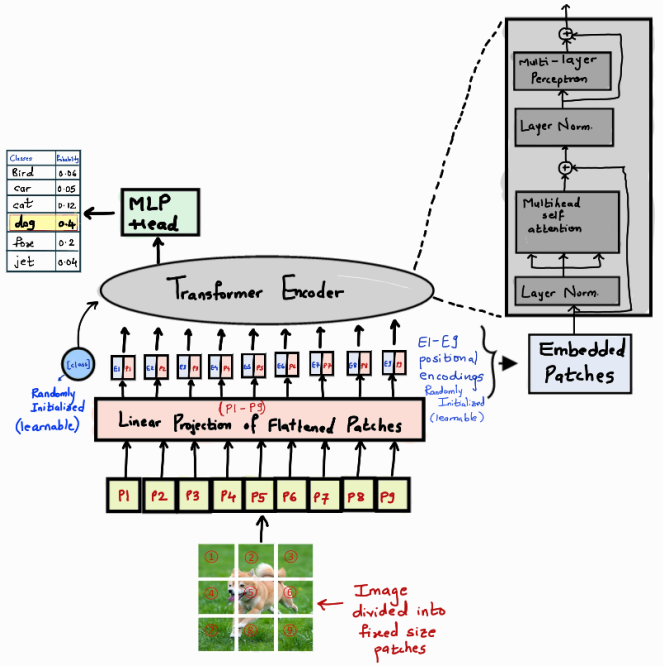

In [ ]:
# Define a VisionTransformer class (nn.Module)
# Constructor:
#   1) image_size   --> heigth and width
#   2) patch_size   --> size of each square patch (patch: piccoli blocchi che suddividono l'immagine)
#   2) num_classes  --> number of classes of final classification layer
#   3) d_model      --> dimensionality of the token embeddings
#   4) depth        --> number of transformer blocks to stack
#   5) num_heads    --> number of attention heads

# Initialization:
#   1) patch embedding layer
#   2) learnable [CLS] token param + learnable pos-embedding param
#   3) sequential stack of transformer blocks
#   4) MLP clssification head

# Forward:
#   Input image tensor
#   Extract embeddings
#   Prepend [CLS] token + Add Pos-Embeddings
#   Pass the sequence to transformer blocks
#   Pass the state of the CLS token to MLP head --> return class logits 
#   (class logits: valori numerici grezzi prodotti dal modello come output finale prima della softmax)



In [19]:
class VisionTransformer(nn.Module):
    def __init__(self, image_size, patch_size, num_classes, d_model, depth, num_heads):
        
        # Inizializzazione
        super().__init__()
        self.image_size = image_size
        self.patch_size = patch_size
        self.num_classes = num_classes
        self.d_model = d_model
        self.depth = depth
        self.num_heads = num_heads
        
        # Patch Embedding Layer
        #   trasforma immagine (a colori, in_channels=3) in una sequenza di token
        self.patch_embedding = nn.Conv2d(3, d_model, patch_size, patch_size)
        
        # CLS Token --> shape(1, 1, d_model) 
        #   --> ricordarsi l'ordine (batch, sequence, dim)
        #   quindi è un vettore di una riga sola
        #   In più è un 'learnable parameter'
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        
        # Positional Embedding --> shape(1, num_patches + 1, d_model)
        #   quindi sono tanti vettori di dimensione d_model in numero pari al numero delle patches create + 1
        #   IMAGE_SIZE E PATCH_SIZE SONO ENTRAMBE QUADRATE!
        num_patches = (image_size // patch_size) ** 2
        self.pos_embeddings = nn.Parameter(torch.zeros(1, num_patches + 1, d_model))
        
        # Transformers Blocks
        self.encoder_layer = nn.TransformerEncoderLayer(d_model, num_heads, batch_first=True)   # il primo canale è il batch (profondità)
        self.transformers = nn.TransformerEncoder(self.encoder_layer, depth)
        
        # MLP Classification Head
        #   d_model --> dimensionality of token embeddings
        #   return class logits
        self.mlphead = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, num_classes)
        )
        
        
    def forward(self, X):
        batch = X.shape[0]
        
        x = self.patch_embedding(X)                   # (batch, d_model, H, W)
        x = x.flatten(2)                              # (batch, d_model, num_patches) --> flat dalla seconda dimensione in poi
        x = x.transpose(1, 2)                         # (batch, num_patches, d_model)
        
        cls = self.cls_token.expand(batch, -1, -1)    # per aggiungerlo al tensore X, che ha la prima dimensone = batch, lo devo espandere
        x = torch.cat((cls, x), dim=1)                # aggiunge il token cls come prima riga --> (batch, num_patches + 1, d_model)
        
        x = x + self.pos_embeddings                   # broadcasting (su ogni elemento)
        
        x = self.transformers(x)                      # i transformers non cambiano la size di x
            
        cls_out = x[:, 0, :]                          # prendo il cls token di uscita (B, 1, d_model)
        
        logits = self.mlphead(cls_out)
        
        return logits
        
        

#### TESTING

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
# image opening and pre-processing
input = Image.open('lenna.jpg')

input = torch.from_numpy(np.array(input, dtype=np.float32)).permute(2, 0, 1)
input = input.unsqueeze(0)
input = input.to(torch.float32)

# input shape: (batch, channelss, H, W)
print("input shape:", input.shape)

input shape: torch.Size([1, 3, 512, 512])


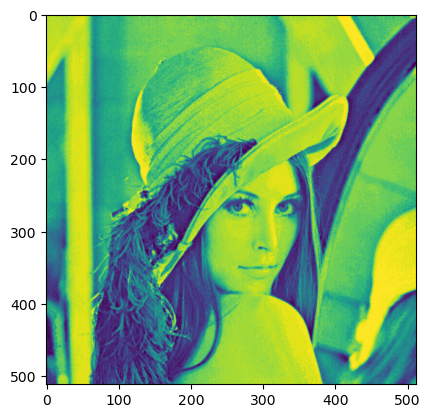

In [17]:
# INPUT
plt.imshow(input[0, 0].numpy())

In [20]:
ViT = VisionTransformer(512, 32, 2, 64, 12, 4)
logits = ViT.forward(input)

In [ ]:
# Avendo i pesi inizializzati casualmente e non essendoci training i logits non hanno 
# nessun significato! Però ne ritorna due, che si riferiscono al numero di classi specificate
# in input. In questo caso quindi 'num_classes' definisce solo la dimesione dell'output

logits

# Questo l'ho fatto per l'80% da solo, quindi geggio non rompere i coglioni

tensor([[-0.0317, -0.5867]], grad_fn=<AddmmBackward0>)

In [ ]:
# Per avvalorare che i logits sono casuali

import torch.nn.functional as F

probs = F.softmax(logits, dim=1)
print(probs)

tensor([[0.6353, 0.3647]], grad_fn=<SoftmaxBackward0>)
